In [1]:
# --- Step 1: Libraries and Data Loading ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import joblib
import os


data_path = 'Data/bug_dataset_50k.csv'
df = pd.read_csv(data_path)

# Logic Injection: Creating a smart relationship between features and target
def assign_logic(row):
    text = f"{str(row['title'])} {str(row['description'])}".lower()
    # Critical Logic
    if any(word in text for word in ['crash', 'security', 'leak', 'fatal', 'vulnerability']): 
        return 'Critical'
    # High Logic
    if 'production' in str(row['environment']).lower() or any(word in text for word in ['api', 'database', 'timeout']): 
        return 'High'
    # Medium Logic
    if 'staging' in str(row['environment']).lower() or 'backend' in str(row['developer_role']).lower(): 
        return 'Medium'
    # Default
    return 'Low'

df['severity'] = df.apply(assign_logic, axis=1)
print(f"Successfully loaded {len(df)} records.")
print("New Class Distribution:\n", df['severity'].value_counts())

Successfully loaded 50000 records.
New Class Distribution:
 severity
High        18431
Medium      14048
Low         11180
Critical     6341
Name: count, dtype: int64


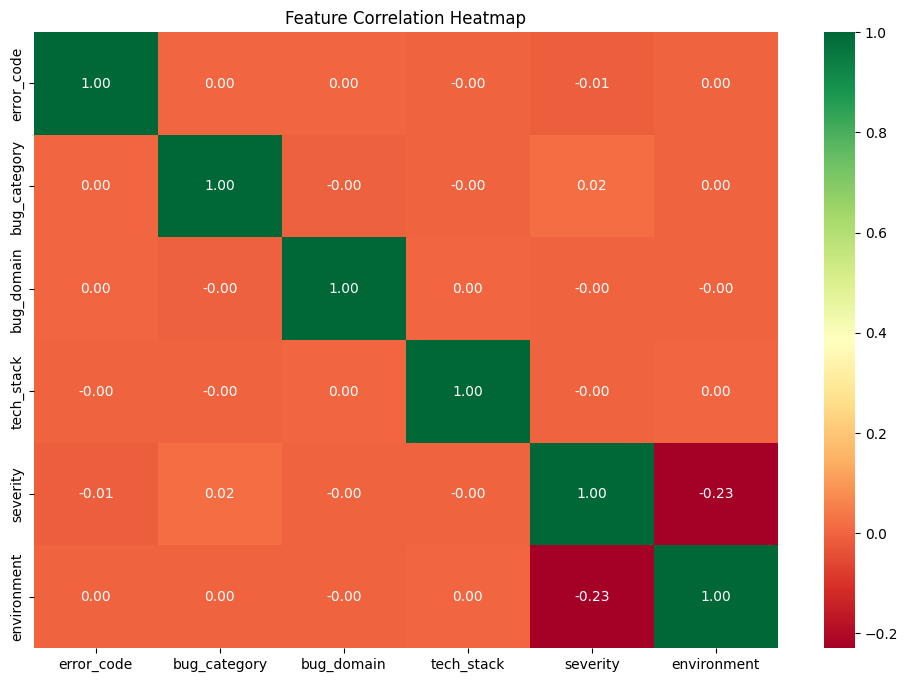

Correlation with Severity:
 severity        1.000000
bug_category    0.016451
bug_domain     -0.001772
tech_stack     -0.003502
error_code     -0.009351
environment    -0.229372
Name: severity, dtype: float64


In [2]:
# --- Step 2: Exploratory Data Analysis (EDA) ---

df_corr = df.copy()
cols_to_encode_eda = ['bug_category', 'tech_stack', 'environment', 'severity', 'bug_domain']

# Safely encode categorical columns for correlation visualization
for col in cols_to_encode_eda:
    if col in df_corr.columns:
        df_corr[col] = pd.factorize(df_corr[col])[0]

plt.figure(figsize=(12, 8))
# Drop non-numeric IDs and timestamps for correlation, select only numeric columns
numeric_df = df_corr.drop(columns=['bug_id', 'created_at'], errors='ignore').select_dtypes(include=[np.number])

# Plot the Correlation Heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Print correlation with severity
if 'severity' in numeric_df.columns:
    print("Correlation with Severity:\n", numeric_df.corr()['severity'].sort_values(ascending=False))

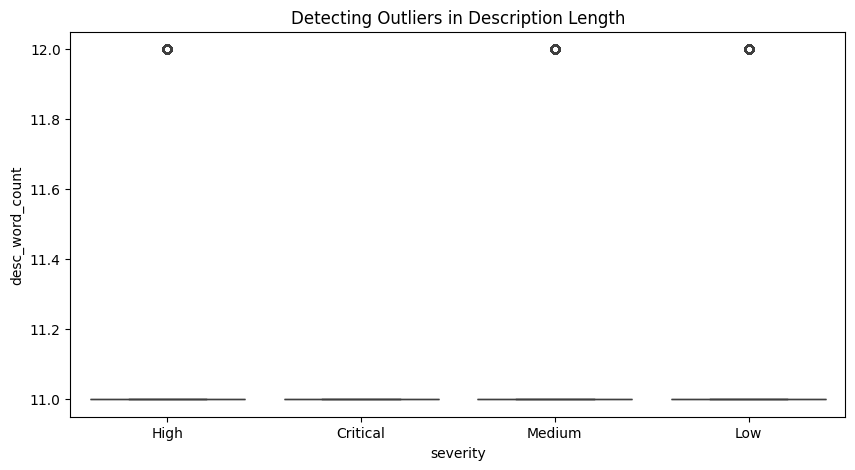

Removed 9261 outlier records.


In [3]:
# --- Step 3: Outlier Detection and Data Cleaning ---
# Calculate word count for descriptions
df['desc_word_count'] = df['description'].apply(lambda x: len(str(x).split()))

# Boxplot for Outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x='severity', y='desc_word_count', data=df)
plt.title("Detecting Outliers in Description Length")
plt.show()

# IQR Method to remove extreme outliers based on description length
Q1 = df['desc_word_count'].quantile(0.25)
Q3 = df['desc_word_count'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

initial_count = len(df)
# Reassign filtered dataframe to df
df = df[df['desc_word_count'] <= upper_limit]
print(f"Removed {initial_count - len(df)} outlier records.")

# Handle Missing Values
if 'error_code' in df.columns:
    df['error_code'] = df['error_code'].fillna(0)

# Fill NaN in title and description to prevent errors during string operations
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')

In [4]:
# --- Step 4 & 5: Feature Engineering & categorical Encoding ---
# Create full text for NLP
df['full_text'] = (df['title'] + " " + df['description']).str.lower()

# Manual Keyword Features
critical_keywords = ['crash', 'emergency', 'security', 'leak', 'broken', 'down', 'fatal', 'vulnerability']
for word in critical_keywords:
    df[f'has_{word}'] = df['full_text'].apply(lambda x: 1 if word in str(x) else 0)

# Categorical Encoding
encoders = {}
cat_cols = ['bug_category', 'bug_domain', 'tech_stack', 'environment', 'developer_role']
for col in cat_cols:
    le = LabelEncoder()
    # Convert to string to avoid errors with potential mixed types
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

target_le = LabelEncoder()
df['target'] = target_le.fit_transform(df['severity'])

# Text Vectorization (TF-IDF)
tfidf = TfidfVectorizer(max_features=70, stop_words='english')
text_features = tfidf.fit_transform(df['full_text']).toarray()

# Feature Matrix Assembly (X)
manual_features = [f'has_{word}' for word in critical_keywords] + [f'{col}_enc' for col in cat_cols] 
if 'error_code' in df.columns:
    manual_features.append('error_code')

X_numeric = df[manual_features].values
X = np.hstack([X_numeric, text_features])
y = df['target']

print(f"Final Feature Matrix Shape: {X.shape}")

Final Feature Matrix Shape: (40739, 36)


Classification Report:
               precision    recall  f1-score   support

    Critical       1.00      1.00      1.00      1249
        High       1.00      1.00      1.00      3111
         Low       1.00      1.00      1.00      1640
      Medium       1.00      1.00      1.00      2148

    accuracy                           1.00      8148
   macro avg       1.00      1.00      1.00      8148
weighted avg       1.00      1.00      1.00      8148



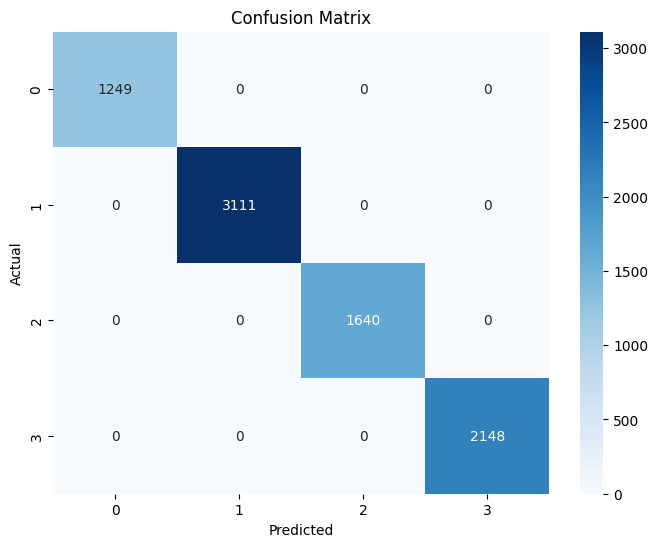

In [5]:
# --- Step 6: Model Training and Evaluation ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_le.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

In [6]:
# --- Step 7: Save Model Assets ---
os.makedirs('models', exist_ok=True)

# Save models and encoders
joblib.dump(model, 'models/xgb_model.pkl')
joblib.dump(encoders, 'models/label_encoders.pkl')
joblib.dump(target_le, 'models/target_encoder.pkl')
joblib.dump(tfidf, 'models/tfidf.pkl')

# Save feature names to ensure alignment during prediction later on
feature_names = manual_features + list(tfidf.get_feature_names_out())
joblib.dump(feature_names, 'models/feature_columns.pkl')

print("✅ All assets saved successfully in the 'models/' directory.")

✅ All assets saved successfully in the 'models/' directory.
